<a href="https://colab.research.google.com/github/PHYS-3510-SPRING-2026/hello-world-Raygarza1243/blob/main/Ray_Garza_Monte_Carlo_and_the_Ising_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-Long Project: Monte Carlo Methods and the 2D Ising Model

**PHYS 3510 — Computational Physics**

---

## Overview

In this project you will build a simulation of one of the most celebrated models in statistical physics: the **2D Ising Model**. Along the way you will use nearly every technique from the last several weeks:

| Technique | Where it appears |
|---|---|
| Root-finding (bisection) | Finding the critical temperature |
| NumPy array operations & slicing | Storing and updating the spin lattice |
| Random number generation | The Metropolis algorithm |
| Statistics & distributions | Energy, magnetization, susceptibility |
| Object-oriented programming | `IsingModel` class and subclasses |

### What is the Ising Model?

Imagine a 2D grid of atoms. Each atom has a **spin** that can point either up (+1) or down (−1) — think of it as a tiny magnet. Neighboring spins interact: they *prefer* to align (same sign). At low temperature the whole lattice orders into one big magnet (**ferromagnetic phase**). At high temperature, thermal fluctuations randomize everything (**paramagnetic phase**). Between these phases lies a **phase transition** at a critical temperature $T_c$.

The Hamiltonian (total energy) is:

$$H = -J \sum_{\langle i,j \rangle} s_i s_j$$

where the sum is over all **nearest-neighbor pairs**, $s_i \in \{-1, +1\}$ is the spin at site $i$, and $J > 0$ is the coupling constant (we will set $J = 1$).

**Lars Onsager** solved this model analytically in 1944. The exact critical temperature is:

$$k_B T_c = \frac{2J}{\ln(1 + \sqrt{2})} \approx 2.269 J$$

Your simulation should recover this value!

---

## Grading & Milestones

| Part | Topic | Points |
|---|---|---|
| 1 | Warm-up: Monte Carlo integration | 15 |
| 2 | Building the `IsingModel` class | 25 |
| 3 | The Metropolis algorithm | 20 |
| 4 | Measuring thermodynamic observables | 20 |
| 5 | Phase transition & critical temperature | 15 |
| 6 | Bonus extensions | up to 15 |

**Submission:** one `.ipynb` file with all cells run, plus a short written response to each "Analysis Question" embedded in the notebook.

---

## Suggested Timeline

| Day | Goal |
|---|---|
| Mon | Part 1 (warm-up) + start Part 2 |
| Tue | Finish Part 2 |
| Wed | Part 3 (Metropolis) |
| Thu | Part 4 (observables) |
| Fri | Part 5 (phase transition) |
| Weekend | Polish, write-up, bonus |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

rng = np.random.default_rng(seed=42)

---
# Part 1 — Warm-Up: Monte Carlo Integration (15 pts)

Before tackling the Ising model, let's practice using random numbers to compute integrals — a technique called **Monte Carlo integration**.

The idea: to estimate $\int_a^b f(x)\,dx$, draw $N$ random points $x_i$ uniformly from $[a, b]$ and compute:

$$\int_a^b f(x)\,dx \approx (b - a) \cdot \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$

This works because the average of $f$ over random samples approximates the true mean of $f$ on $[a, b]$.

### 1a — Estimating $\pi$ (5 pts)

A circle of radius 1 fits inside a $2 \times 2$ square. The fraction of random points $(x, y)$ (with $x, y \in [-1, 1]$) that fall inside the circle equals $\pi / 4$.

**Task:**
1. Generate `N = 100_000` random points $(x, y)$ with both coordinates uniform in $[-1, 1]$.
2. Count how many fall inside the unit circle ($x^2 + y^2 \leq 1$).
3. Use that fraction to estimate $\pi$.
4. Make a scatter plot showing inside points (one color) and outside points (another color). Only plot the first 2000 points so it isn't too slow.

Estimated pi = 3.14060
Exact    pi = 3.14159
Error       = 0.00099


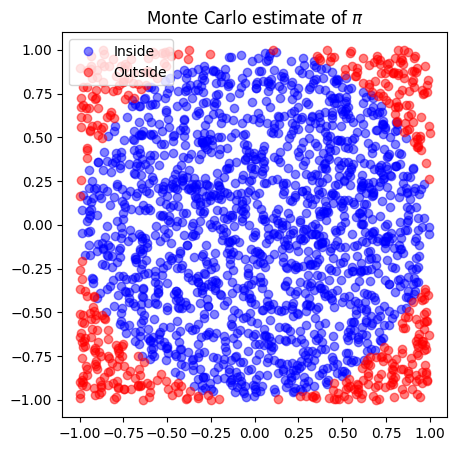

In [3]:
N = 100_000

# Generate N random (x, y) pairs, both in [-1, 1]
x = np.random.uniform(-1, 1, size=N)
y = np.random.uniform(-1, 1, size=N)

# Check if points are inside the unit circle
is_inside = (x**2 + y**2 <= 1)
num_inside = np.sum(is_inside)

# Estimate pi
pi_estimate = 4 * num_inside / N
print(f"Estimated pi = {pi_estimate:.5f}")
print(f"Exact    pi = {np.pi:.5f}")
print(f"Error       = {abs(pi_estimate - np.pi):.5f}")

# Scatter plot — only first 2000 points
fig, ax = plt.subplots(figsize=(5, 5))

# Take only the first 2000 points for plotting
x_plot = x[:2000]
y_plot = y[:2000]
is_inside_plot = is_inside[:2000]

# plot inside points
ax.plot(x_plot[is_inside_plot], y_plot[is_inside_plot], 'o', color='blue', alpha=0.5, label='Inside')
# plot outside points
ax.plot(x_plot[~is_inside_plot], y_plot[~is_inside_plot], 'o', color='red', alpha=0.5, label='Outside')

ax.set_aspect('equal')
ax.set_title(r'Monte Carlo estimate of $\pi$')
ax.legend()
plt.show()

### 1b — Convergence (5 pts)

How does the error in the $\pi$ estimate scale with $N$? For Monte Carlo integration the error should scale as $1/\sqrt{N}$.

**Task:**
1. For each $N$ in `[100, 300, 1000, 3000, 10000, 30000, 100000]`, run the Monte Carlo estimate **20 times** (with different random draws) and record the standard deviation of the 20 estimates.
2. Plot the standard deviation vs $N$ on a log-log plot.
3. Overlay the theoretical line $\sigma \propto N^{-1/2}$ for comparison.

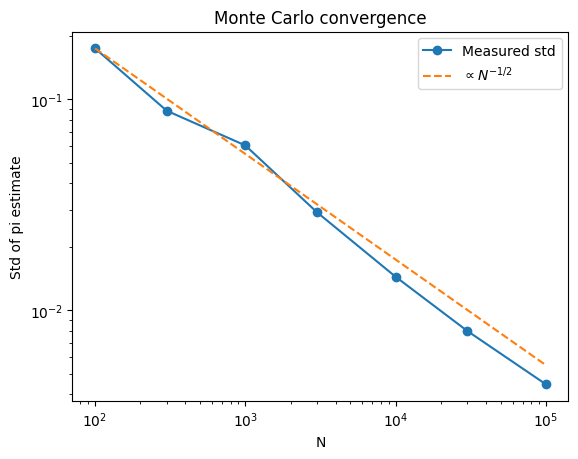

In [4]:
N_values = [100, 300, 1000, 3000, 10000, 30000, 100000]
n_trials = 20
stds = []

for N in N_values:
    estimates = []
    for _ in range(n_trials):
        x = np.random.uniform(-1, 1, size=N)
        y = np.random.uniform(-1, 1, size=N)
        is_inside = (x**2 + y**2 <= 1)
        num_inside = np.sum(is_inside)
        pi_estimate = 4 * num_inside / N
        estimates.append(pi_estimate)
    stds.append(np.std(estimates))

fig, ax = plt.subplots()
ax.loglog(N_values, stds, 'o-', label='Measured std')

# Overlay N^{-1/2} trend line (scaled to match)
N_arr = np.array(N_values, dtype=float)
scale = stds[0] * N_values[0]**0.5   # match first point
ax.loglog(N_arr, scale / np.sqrt(N_arr), '--', label=r'$\propto N^{-1/2}$')

ax.set_xlabel('N')
ax.set_ylabel('Std of pi estimate')
ax.set_title('Monte Carlo convergence')
ax.legend()
plt.show()

### 1c — A harder integral (5 pts)

Use Monte Carlo to estimate:

$$I = \int_0^{\pi} \sin(x)\,dx$$

The exact answer is 2.

**Task:**
1. Implement the 1D Monte Carlo integral formula with `N = 50_000`.
2. Print your estimate and the error.
3. **(Analysis Question 1):** Could you compute this integral with regular Riemann sums instead? What advantage does Monte Carlo have when the integral is over a *high-dimensional* domain? Write 2–3 sentences.

In [5]:
N = 50_000
a, b = 0, np.pi

x_samples = np.random.uniform(a, b, size=N)
I_estimate = np.mean(np.sin(x_samples)) * (b - a)

print(f"Monte Carlo estimate: {I_estimate:.5f}")
print(f"Exact value:          2.00000")
print(f"Error:                {abs(I_estimate - 2):.5f}")

Monte Carlo estimate: 1.99992
Exact value:          2.00000
Error:                0.00008


In [ ]:
# Yes this integral can be computed with Riemann sums. Monte Carlo error scales as N^(-1/2) regardless of the number of dimensions.

---
# Part 2 — Building the `IsingModel` Class (25 pts)

We will represent the spin lattice as a 2D NumPy array of shape `(L, L)` where each entry is +1 or −1. We will use **periodic boundary conditions**: spins on the right edge are neighbors of spins on the left edge (and similarly top/bottom). This avoids edge effects and lets us simulate a small patch of a much larger system.

### Periodic boundary conditions reminder

For a 1D array of length $L$, the neighbor to the right of site $i$ is site $(i+1) \% L$, and the neighbor to the left is $(i-1) \% L$. NumPy's `np.roll` does exactly this:

```python
arr = np.array([1, 2, 3, 4, 5])
np.roll(arr, -1)   # [2, 3, 4, 5, 1]  (shift left by 1)
np.roll(arr,  1)   # [5, 1, 2, 3, 4]  (shift right by 1)
```

For a 2D lattice `spins` of shape `(L, L)`, the four nearest-neighbor sums at each site can be written:

```python
neighbor_sum = (np.roll(spins,  1, axis=0) +   # neighbor above
                np.roll(spins, -1, axis=0) +   # neighbor below
                np.roll(spins,  1, axis=1) +   # neighbor left
                np.roll(spins, -1, axis=1))    # neighbor right
```

This gives a `(L, L)` array where entry `[i, j]` is the sum of the four spins neighboring site `(i, j)`.

### 2a — Initialize the lattice (5 pts)

Complete the `__init__` method of the `IsingModel` class below. The constructor should:
- Store `L`, `J`, and `T` as instance attributes.
- Create a `self.spins` array of shape `(L, L)` where each spin is randomly +1 or −1.
- Compute and store the initial energy `self.energy` using `self._total_energy()`.
- Compute and store the initial magnetization `self.magnetization` using `self._total_magnetization()`.

In [6]:
class IsingModel:
    """
    2D Ising Model on an L x L periodic lattice.

    Parameters
    ----------
    L : int
        Linear size of the lattice (L x L spins total).
    J : float
        Coupling constant. J > 0 favors alignment (ferromagnet).
    T : float
        Temperature (in units where k_B = 1).
    seed : int, optional
        Random seed for reproducibility.
    """

    def __init__(self, L, J=1.0, T=2.0, seed=None):
        self.L = L
        self.J = J
        self.T = T
        self.rng = np.random.default_rng(seed)

        # Initialize spins: random array of +1 and -1, shape (L, L)
        self.spins = self.rng.choice([-1, 1], size=(L, L))

        # Compute initial energy and magnetization
        self.energy = self._total_energy()
        self.magnetization = self._total_magnetization()

    # ------------------------------------------------------------------ #
    #  Private helper methods                                              #
    # ------------------------------------------------------------------ #

    def _neighbor_sum(self):
        """Return (L, L) array of nearest-neighbor spin sums (periodic BC)."""
        s = self.spins
        return (np.roll(s,  1, axis=0) +
                np.roll(s, -1, axis=0) +
                np.roll(s,  1, axis=1) +
                np.roll(s, -1, axis=1))

    def _total_energy(self):
        """
        Compute total energy: H = -J * sum_{neighbors} s_i * s_j.

        Hint: self.spins * self._neighbor_sum() gives s_i * (sum of neighbors).
        Each pair is counted twice, so divide by 2.
        """
        return -self.J * np.sum(self.spins * self._neighbor_sum()) / 2

    def _total_magnetization(self):
        """Compute total magnetization: M = sum of all spins."""
        return np.sum(self.spins)

    # ------------------------------------------------------------------ #
    #  Visualization                                                       #
    # ------------------------------------------------------------------ #

    def show(self, ax=None, title=None):
        """
        Display the current spin configuration.
        Blue = spin up (+1), Red = spin down (-1).
        """
        if ax is None:
            fig, ax = plt.subplots(figsize=(5, 5))
        cmap = mcolors.ListedColormap(['red', 'blue'])
        ax.imshow(self.spins, cmap=cmap, vmin=-1, vmax=1, interpolation='nearest')
        ax.axis('off')
        if title:
            ax.set_title(title)
        return ax

### 2b — Test the initialization (5 pts)

Run the cell below to test your `__init__`. You should see:
1. A random-looking red/blue lattice (roughly equal amounts of each).
2. A printed energy and magnetization.

**Sanity check:** For a random $L \times L$ lattice, the expected energy per spin is approximately $0$ (since random spins have no tendency to align). The expected magnetization is close to $0$ for large $L$.

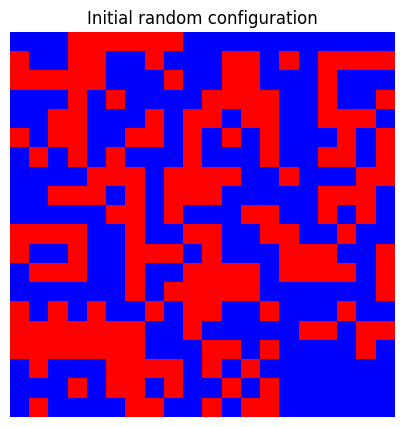

Energy per spin:        -0.1600
Magnetization per spin: 0.1050


In [7]:
model = IsingModel(L=20, J=1.0, T=3.0, seed=0)
model.show(title='Initial random configuration')
plt.show()

N_spins = model.L**2
print(f"Energy per spin:        {model.energy / N_spins:.4f}")
print(f"Magnetization per spin: {model.magnetization / N_spins:.4f}")

### 2c — Energy of a single-spin flip (10 pts)

When we later run the simulation, we will propose flipping one spin at a time. We need to efficiently compute how much the energy **changes** when spin $(i, j)$ is flipped.

If spin $(i,j)$ has value $s$ and the sum of its four neighbors is $S_{\rm nb}$, then:
- **Before flip:** contribution to $H$ is $-J \cdot s \cdot S_{\rm nb}$
- **After flip:** contribution to $H$ is $-J \cdot (-s) \cdot S_{\rm nb}$
- **Energy change:** $\Delta E = 2 J s \cdot S_{\rm nb}$

Add the method `_delta_energy(i, j)` to `IsingModel`. It should return $\Delta E$ for flipping spin $(i, j)$, using periodic boundary conditions for the neighbor lookup.

*Hint:* You can access neighbors as:
```python
s = self.spins
L = self.L
nb_sum = s[(i+1)%L, j] + s[(i-1)%L, j] + s[i, (j+1)%L] + s[i, (j-1)%L]
```

In [8]:
# Add _delta_energy to the IsingModel class by redefining it here.
# (In a real project you would add it directly above —
#  here we monkey-patch for convenience.)

def _delta_energy(self, i, j):
    """
    Energy change if spin (i, j) is flipped.
    Returns: delta_E = 2 * J * s[i,j] * (sum of 4 neighbors)
    """
    s = self.spins
    L = self.L
    nb_sum = s[(i+1)%L, j] + s[(i-1)%L, j] + s[i, (j+1)%L] + s[i, (j-1)%L]
    return 2 * self.J * s[i, j] * nb_sum

IsingModel._delta_energy = _delta_energy

# Quick test: flip a spin and verify energy changes by delta_E
model_test = IsingModel(L=10, seed=1)
E_before = model_test._total_energy()
dE = model_test._delta_energy(3, 4)
model_test.spins[3, 4] *= -1          # actually flip it
E_after = model_test._total_energy()
print(f"Predicted dE : {dE:.4f}")
print(f"Actual    dE : {E_after - E_before:.4f}")
print(f"Match: {np.isclose(dE, E_after - E_before)}")

Predicted dE : 4.0000
Actual    dE : 4.0000
Match: True


### 2d — Analysis Question 2 (5 pts)

**Analysis Question 2:** Why do we compute $\Delta E$ with the formula above instead of recomputing the total energy from scratch after each flip? How much computation does this save for an $L \times L$ lattice? Express your answer in terms of $L$.

In [ ]:
# We compute Δ𝐸 with the formula because computing the total energy from scratch intergrates over all LxL spins (O(L^2) operation). Computing Δ𝐸 only makes it an O(1) operation.

---
# Part 3 — The Metropolis Algorithm (20 pts)

The **Metropolis algorithm** is the core of our simulation. It generates configurations of spins according to the Boltzmann probability distribution:

$$P(\text{config}) \propto e^{-H/k_B T}$$

Low-energy configurations are exponentially more probable at low temperature.

**One Metropolis step:**
1. Pick a spin $(i, j)$ at random.
2. Compute $\Delta E$, the energy change if this spin is flipped.
3. **If $\Delta E \leq 0$:** always accept the flip (lower energy → always favorable).
4. **If $\Delta E > 0$:** accept the flip with probability $e^{-\Delta E / T}$ (sometimes an unfavorable flip is accepted due to thermal fluctuations).

One **sweep** = $L^2$ Metropolis steps (on average, every spin is proposed once).

### 3a — Implement one Metropolis sweep (10 pts)

Add a `sweep()` method to `IsingModel`. It should:
1. Perform $L^2$ single-spin flip attempts.
2. After each accepted flip, update `self.energy` and `self.magnetization` using $\Delta E$ and $\Delta M = -2 s_{ij}$ (before flip).
3. Return the number of accepted flips (useful for monitoring).

In [9]:
def sweep(self):
    """
    Perform L^2 Metropolis spin-flip attempts.
    Updates self.spins, self.energy, self.magnetization in place.
    Returns: number of accepted flips.
    """
    L = self.L
    T = self.T
    n_accept = 0

    for _ in range(L * L):
        # Step 1: pick a random spin site
        i = self.rng.integers(0, L)
        j = self.rng.integers(0, L)

        # Step 2: compute energy change for flipping spin (i,j)
        dE = self._delta_energy(i, j)

        # Step 3 & 4: accept or reject
        if dE <= 0 or self.rng.random() < np.exp(-dE / T):
            # Accept: flip the spin
            delta_M = -2 * self.spins[i, j]   # change in magnetization
            self.spins[i, j] *= -1

            # Update running totals
            self.energy += dE
            self.magnetization += delta_M
            n_accept += 1

    return n_accept

IsingModel.sweep = sweep

### 3b — Run and visualize (10 pts)

**Task:**
1. Create an `IsingModel` with `L=40`, `T=1.5` (cold — should order).
2. Run it for 500 sweeps, storing `energy/N` and `|magnetization|/N` after each sweep.
3. Plot both vs. sweep number. You should see the system **equilibrate** from its random initial state.
4. Show the final spin configurations for the cold and hot runs side by side.
5. Repeat for `T=3.5` (hot — should stay disordered).

In [10]:
def run_simulation(L, T, n_sweeps, seed=0):
    """Run for n_sweeps and return energy and |magnetization| per spin."""
    model = IsingModel(L=L, T=T, seed=seed)
    N = L * L
    energies = [model.energy / N]
    mags = [abs(model.magnetization) / N]

    for _ in range(n_sweeps):
        model.sweep()
        energies.append(model.energy / N)
        mags.append(abs(model.magnetization) / N)

    return model, np.array(energies), np.array(mags)

# --- Cold simulation (T < T_c ≈ 2.269) ---
model_cold, E_cold, M_cold = run_simulation(L=40, T=1.5, n_sweeps=500)

# --- Hot simulation (T > T_c) ---
model_hot, E_hot, M_hot = run_simulation(L=40, T=3.5, n_sweeps=500)

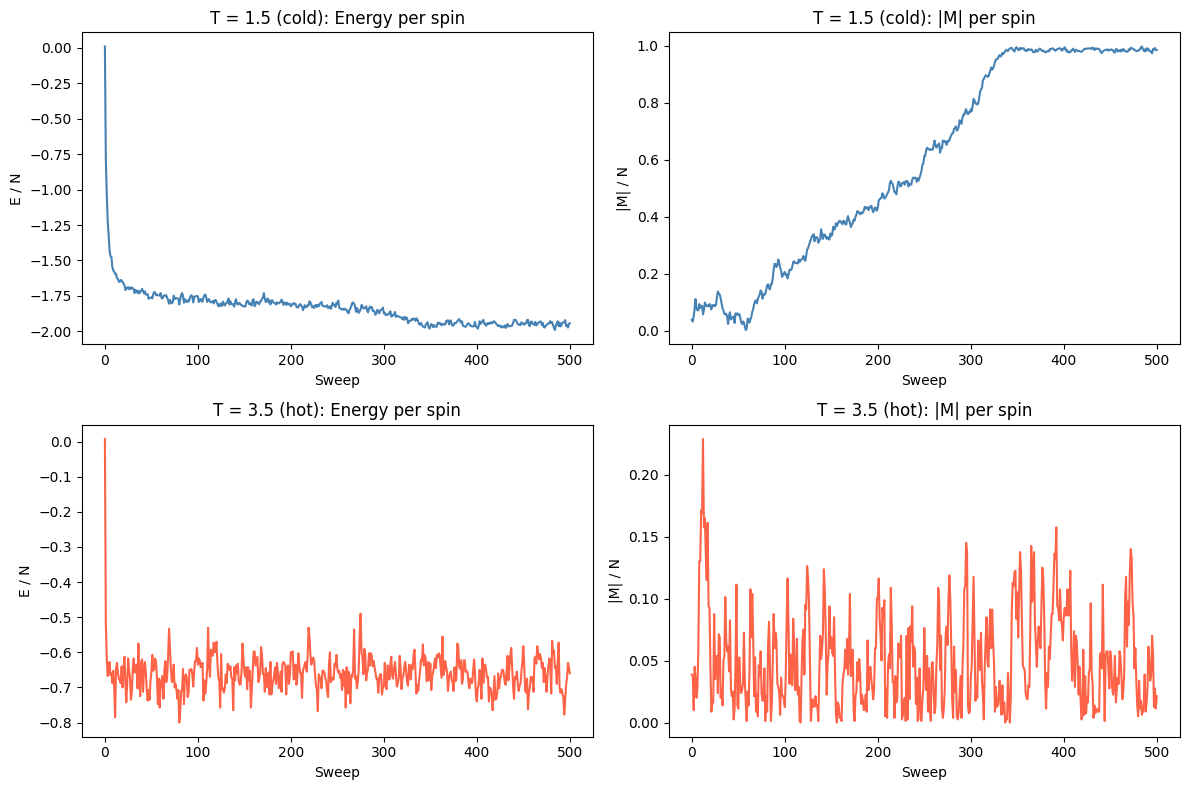

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Energy and magnetization plots for both temperatures
sweeps = np.arange(len(E_cold))

axes[0, 0].plot(sweeps, E_cold, color='steelblue')
axes[0, 0].set_title('T = 1.5 (cold): Energy per spin')
axes[0, 0].set_xlabel('Sweep')
axes[0, 0].set_ylabel('E / N')

axes[0, 1].plot(sweeps, M_cold, color='steelblue')
axes[0, 1].set_title('T = 1.5 (cold): |M| per spin')
axes[0, 1].set_xlabel('Sweep')
axes[0, 1].set_ylabel('|M| / N')

axes[1, 0].plot(sweeps, E_hot, color='tomato')
axes[1, 0].set_title('T = 3.5 (hot): Energy per spin')
axes[1, 0].set_xlabel('Sweep')
axes[1, 0].set_ylabel('E / N')

axes[1, 1].plot(sweeps, M_hot, color='tomato')
axes[1, 1].set_title('T = 3.5 (hot): |M| per spin')
axes[1, 1].set_xlabel('Sweep')
axes[1, 1].set_ylabel('|M| / N')

plt.tight_layout()
plt.show()

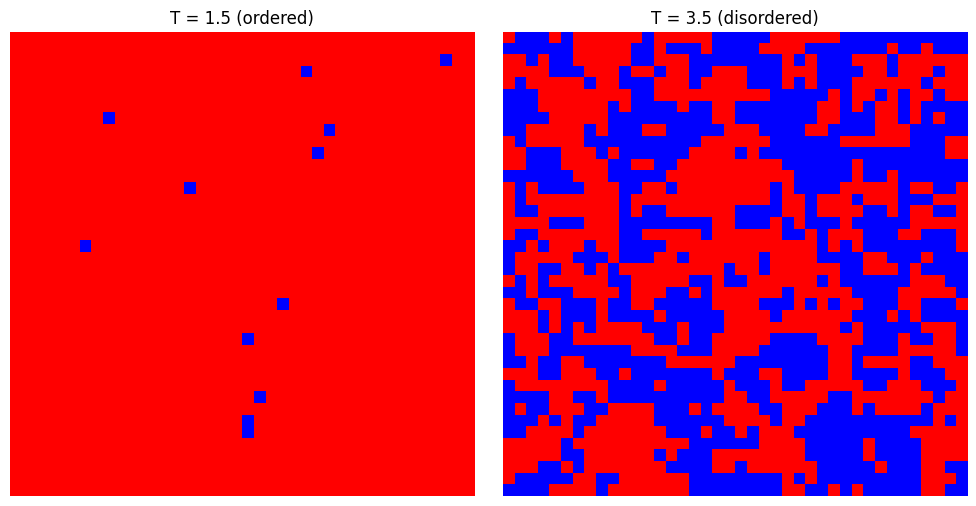

In [20]:
# Show final spin configurations
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
model_cold.show(ax=axes[0], title='T = 1.5 (ordered)')
model_hot.show(ax=axes[1], title='T = 3.5 (disordered)')
plt.tight_layout()
plt.show()

**Analysis Question 3:** Describe what you observe in the spin configurations for the two temperatures. Why does the cold system order, while the hot system doesn't? Relate your answer to the energy terms in the Hamiltonian and the Boltzmann factor.

In [ ]:
# For cold temp, the spin configuration is mostly aligned in one direction (mainly red), kbT is much smaller at lower temps than coupling constant J.
# For hot temp, the spin configuration has a mix of red and blue, kbT is much larger at higher temps than coupling constant J.

---
# Part 4 — Measuring Thermodynamic Observables (20 pts)

Now that the simulation runs, we want to measure **equilibrium averages** — the mean values of physical quantities after the system has forgotten its random initial state.

### Equilibration vs. measurement

The system needs time to equilibrate from the random initial state. We will:
1. **Discard** the first `n_eq` sweeps (the "burn-in" or "thermalization" period).
2. **Average** over the next `n_meas` sweeps.

### Observables we will measure

For an $L \times L$ lattice with $N = L^2$ spins:

| Observable | Formula | Meaning |
|---|---|---|
| Mean energy per spin | $\langle e \rangle = \langle E \rangle / N$ | Average energy |
| Mean magnetization per spin | $\langle m \rangle = \langle |M| \rangle / N$ | Average order |
| Specific heat | $C = (\langle E^2 \rangle - \langle E \rangle^2) / (N T^2)$ | Energy fluctuations |
| Susceptibility | $\chi = (\langle |M|^2 \rangle - \langle |M| \rangle^2) / (N T)$ | Magnetization fluctuations |

Specific heat and susceptibility **peak near the critical temperature** — this is how we will locate $T_c$.

> **Why $|M|$?** Because the system can spontaneously magnetize in either the +1 or −1 direction. Using $|M|$ makes the susceptibility well-defined regardless of which direction the system picks.

### 4a — `measure()` method (10 pts)

Add a `measure(n_eq, n_meas)` method to `IsingModel`. It should:
1. Run `n_eq` sweeps (thermalization — discard these).
2. Run `n_meas` sweeps, collecting $E$ and $|M|$ at every sweep.
3. Compute and return a dictionary with keys `'e'`, `'m'`, `'C'`, `'chi'`.

In [13]:
def measure(self, n_eq=200, n_meas=500):
    """
    Thermalize for n_eq sweeps, then measure for n_meas sweeps.

    Returns dict with keys:
        'e'   : mean energy per spin
        'm'   : mean |magnetization| per spin
        'C'   : specific heat per spin
        'chi' : susceptibility per spin
    """
    N = self.L ** 2
    T = self.T

    # Thermalization
    for _ in range(n_eq):
        self.sweep()

    # Measurement
    E_arr = np.zeros(n_meas)
    M_arr = np.zeros(n_meas)

    for k in range(n_meas):
        self.sweep()
        E_arr[k] = n_meas * self.energy / N  # current E (not per spin yet)
        M_arr[k] = n_meas * self.magnetization / N  # current |magnetization| (not per spin yet)

    # Compute averages
    mean_e = np.mean(E_arr) / N
    mean_m = np.mean(np.abs(M_arr)) / N

    # Specific heat: Var(E) / (N T^2)
    C = (np.mean(E_arr**2) - mean_e**2) / (N * T**2)

    # Susceptibility: Var(|M|) / (N T)
    chi = (np.mean(M_arr**2) - mean_m**2) / (N * T)

    return {'e': mean_e, 'm': mean_m, 'C': C, 'chi': chi}

IsingModel.measure = measure

# Quick test
model_test = IsingModel(L=20, T=2.0, seed=42)
results = model_test.measure(n_eq=200, n_meas=300)
print("T = 2.0 (just below T_c ≈ 2.269):")
for k, v in results.items():
    print(f"  {k:4s} = {v:.4f}")

T = 2.0 (just below T_c ≈ 2.269):
  e    = -1.3225
  m    = 0.6915
  C    = 175.2062
  chi  = 95.7508


### 4b — Observables vs. temperature (10 pts)

Sweep a range of temperatures and measure all four observables. This will take a few minutes — be patient!

**Task:**
1. Use `L=24` and the temperature range given below.
2. Plot all four observables ($\langle e \rangle$, $\langle m \rangle$, $C$, $\chi$) vs. $T$ in a 2×2 grid.
3. Mark $T_c \approx 2.269$ on each plot with a vertical dashed line.
4. Describe in a short answer what happens to each observable near $T_c$.

In [14]:
L = 24
T_values = np.linspace(1.0, 3.5, 25)   # Changed to start from 1.0
T_c_exact = 2.0 / np.log(1 + np.sqrt(2))  # ≈ 2.269

results_list = []
for T in T_values:
    print(f"Running T = {T:.3f}...", end='\r')
    model = IsingModel(L=L, T=T, seed=0)
    res = model.measure(n_eq=300, n_meas=500)
    results_list.append(res)

print("Done!                  ")

# Unpack results
e_vals   = np.array([r['e']   for r in results_list])
m_vals   = np.array([r['m']   for r in results_list])
C_vals   = np.array([r['C']   for r in results_list])
chi_vals = np.array([r['chi'] for r in results_list])

Done!                  


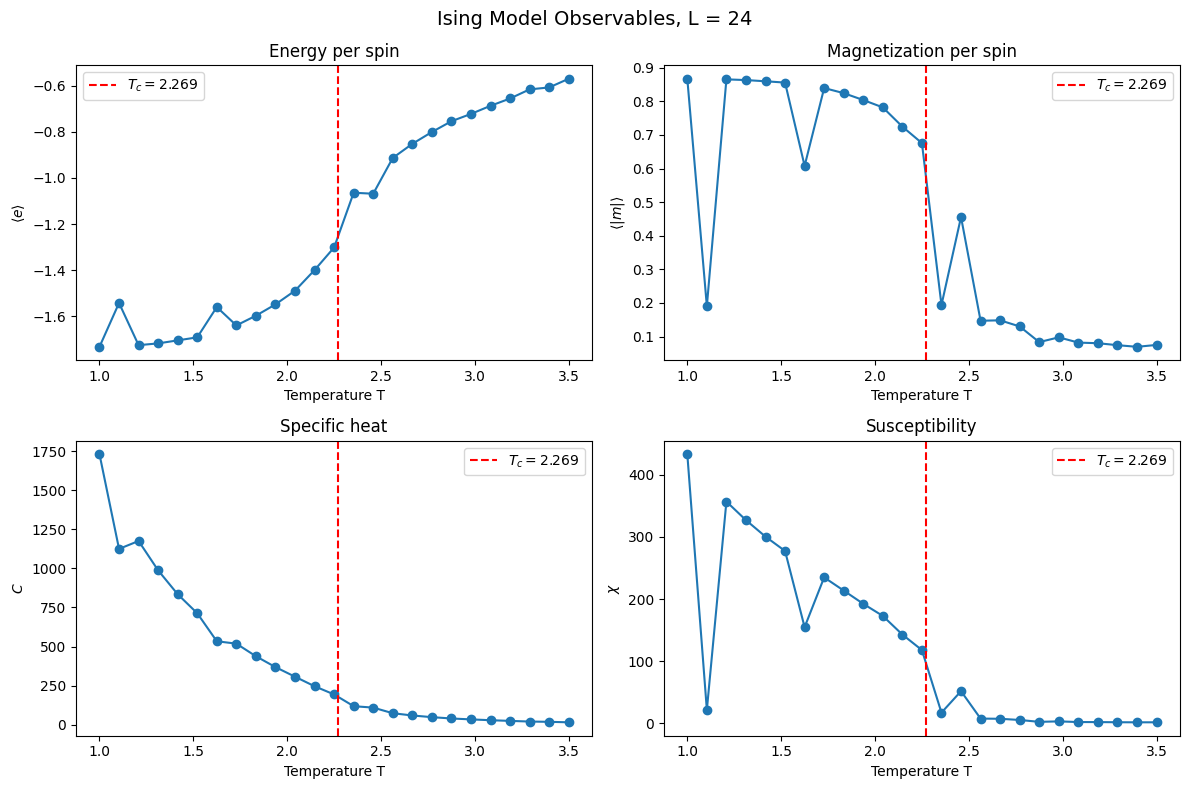

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_data = [
    (axes[0,0], e_vals,   r'$\langle e \rangle$',   'Energy per spin'),
    (axes[0,1], m_vals,   r'$\langle |m| \rangle$', 'Magnetization per spin'),
    (axes[1,0], C_vals,   r'$C$',                   'Specific heat'),
    (axes[1,1], chi_vals, r'$\chi$',                'Susceptibility'),
]

for ax, data, ylabel, title in plot_data:
    ax.plot(T_values, data, 'o-')
    ax.axvline(T_c_exact, color='red', linestyle='--', label=f'$T_c = {T_c_exact:.3f}$')
    ax.set_xlabel('Temperature T')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

plt.suptitle(f'Ising Model Observables, L = {L}', fontsize=14)
plt.tight_layout()
plt.show()

**Analysis Question 4:** Describe the behavior of each of the four observables near $T_c$. Which observables show a *peak* near $T_c$, and which show an *abrupt change*? Why do you think the fluctuation quantities (C and χ) peak at the critical temperature? (3–5 sentences)

In [ ]:
# Energy per spin: Slope near Tc indicates a continuous phase transition.
# Magnetization per spin: Decreases towards zero abruptly.
# Specific heat: sharp peak near Tc.
# Susceptibility: sharp peak near Tc.
# The fluctuations peak for when the system changes the most between different phases.

---
# Part 5 — The Phase Transition and Critical Temperature (15 pts)

The susceptibility $\chi$ peaks near $T_c$. We can use this to **numerically locate** the critical temperature.

### 5a — Fit a parabola to the susceptibility peak (5 pts)

Use `np.polyfit` to fit a quadratic (degree-2 polynomial) to the susceptibility data near the peak. Find the peak location from the fitted polynomial.

*Hint:* The peak of a parabola $p(T) = a_0 T^2 + a_1 T + a_2$ is at $T_{\rm peak} = -a_1 / (2 a_0)$.

Fitted T_c    = 1.1385
Exact  T_c    = 2.2692
Error         = 1.1307


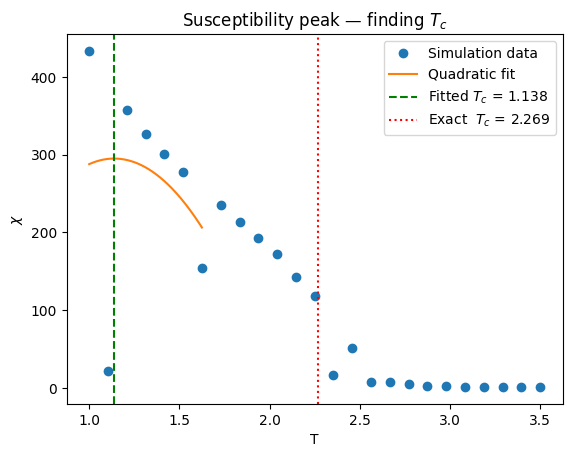

In [21]:
# Restrict to temperatures within ±0.7 of the peak to get a cleaner fit
T_peak_idx = np.argmax(chi_vals)
T_peak_rough = T_values[T_peak_idx]
mask = np.abs(T_values - T_peak_rough) < 0.7

T_fit = T_values[mask]
chi_fit = chi_vals[mask]

# Fit a quadratic
coeffs = np.polyfit(T_fit, chi_fit, deg=2)
a0, a1, a2 = coeffs

T_c_fit = -a1 / (2 * a0)   # peak of parabola
print(f"Fitted T_c    = {T_c_fit:.4f}")
print(f"Exact  T_c    = {T_c_exact:.4f}")
print(f"Error         = {abs(T_c_fit - T_c_exact):.4f}")

# Plot the fit
T_smooth = np.linspace(T_fit.min(), T_fit.max(), 200)
chi_smooth = np.polyval(coeffs, T_smooth)

plt.figure()
plt.plot(T_values, chi_vals, 'o', label='Simulation data')
plt.plot(T_smooth, chi_smooth, '-', label='Quadratic fit')
plt.axvline(T_c_fit,   color='green', linestyle='--', label=f'Fitted $T_c$ = {T_c_fit:.3f}')
plt.axvline(T_c_exact, color='red',   linestyle=':',  label=f'Exact  $T_c$ = {T_c_exact:.3f}')
plt.xlabel('T')
plt.ylabel(r'$\chi$')
plt.title('Susceptibility peak — finding $T_c$')
plt.legend()
plt.show()

### 5b — Find $T_c$ with bisection (10 pts)

The susceptibility $\chi$ peaks at $T_c$. This means its derivative $d\chi/dT$ changes sign there: it is **positive** (χ is rising) just below $T_c$ and **negative** (χ is falling) just above $T_c$. This sign change is exactly what bisection needs.

We can approximate the derivative numerically at each interior temperature point:

$$\frac{d\chi}{dT}\bigg|_i \approx \frac{\chi_{i+1} - \chi_{i-1}}{T_{i+1} - T_{i-1}}$$

**Task:**
1. Compute the numerical derivative $d\chi/dT$ at each interior temperature.
2. Verify that it changes sign near $T_c$ by plotting $d\chi/dT$ vs. $T$.
3. Build a linear interpolant of $d\chi/dT$ vs. $T$ using `np.interp`, and define `f(T)` as this interpolant.
4. Identify a bracket `[a, b]` where `f(a) > 0` and `f(b) < 0` (i.e., straddling the zero).
5. Use the **bisection method** from notebook 15 to find $T_c$ where $d\chi/dT = 0$.
6. Report your estimate and compare to the exact value.

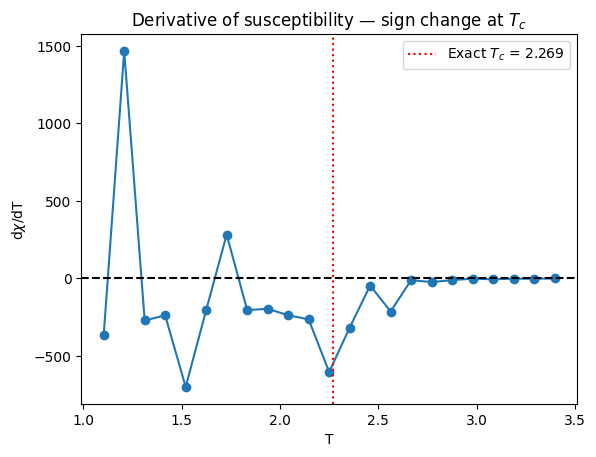

Bisection T_c = 1.7897
Exact     T_c = 2.2692
Error         = 0.4795


In [22]:
# Step 1: Numerical derivative dχ/dT at interior temperature points
dchi_dT = np.zeros(len(chi_vals))
for i in range(1, len(chi_vals) - 1):
    dchi_dT[i] = (chi_vals[i+1] - chi_vals[i-1]) / (T_values[i+1] - T_values[i-1])

# Drop the endpoints (one-sided differences are less accurate)
T_inner  = T_values[1:-1]
dchi_inner = dchi_dT[1:-1]

# Step 2: Plot dχ/dT to see the sign change near T_c
plt.figure()
plt.plot(T_inner, dchi_inner, 'o-')
plt.axhline(0, color='k', linestyle='--')
plt.axvline(T_c_exact, color='red', linestyle=':', label=f'Exact $T_c$ = {T_c_exact:.3f}')
plt.xlabel('T')
plt.ylabel(r'd$\chi$/dT')
plt.title(r'Derivative of susceptibility — sign change at $T_c$')
plt.legend()
plt.show()

# Step 3: Define f(T) using np.interp (linear interpolant of dχ/dT)
def f_bisect(T):
    """Returns dχ/dT at temperature T via linear interpolation."""
    return np.interp(T, T_inner, dchi_inner)

# Step 4: Bisection method (from notebook 15)
def bisection(f, a, b, tol=1e-4):
    """
    Find a zero of f in [a, b] by bisection.
    Requires f(a) and f(b) to have opposite signs.
    """
    assert f(a) * f(b) < 0, "f(a) and f(b) must have opposite signs"
    while (b - a) > tol:
        mid = (a + b)/ 2
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
    return (a + b) / 2

# Step 5: Choose a bracket straddling the zero of dχ/dT
# (Hint: look at your plot — pick one T below T_c where dχ/dT > 0,
#  and one T above T_c where dχ/dT < 0)
a_bracket = 1.729  # temperature where dχ/dT > 0
b_bracket = 1.833 # temperature where dχ/dT < 0

T_c_bisect = bisection(f_bisect, a_bracket, b_bracket)
print(f"Bisection T_c = {T_c_bisect:.4f}")
print(f"Exact     T_c = {T_c_exact:.4f}")
print(f"Error         = {abs(T_c_bisect - T_c_exact):.4f}")

**Analysis Question 5:** Your simulation uses a finite lattice ($L = 24$). The exact $T_c \approx 2.269$ is for an *infinite* lattice. Would you expect your simulated $T_c$ to be above or below the exact value? Why? (This is related to "finite-size effects" — look it up if you need to, and explain in 2–3 sentences.)

In [ ]:
# I would expect Tc to be below due to the finite-size of the system simulation. As the lattice size increases, the Tc approaches the exact from below from the critial temp being cut off in a finite system.

---
# Part 6 — Bonus Extensions (up to 15 pts)

Choose **one or more** of the following extensions. Each is worth up to 5 pts. Clearly label which bonus(es) you are attempting.

---

### Bonus A — OOP Extension: `IsingModelCold` subclass (5 pts)

Create a subclass `IsingModelCold(IsingModel)` that overrides `__init__` to start from an **ordered** initial state (all spins +1) instead of a random one. All other methods should be inherited unchanged.

- Run both `IsingModel` and `IsingModelCold` at `T = 2.0` for 500 sweeps each.
- Plot magnetization vs. sweep for both, on the same axes.
- **Analysis:** Do they converge to the same equilibrium value? How many sweeps does each need to equilibrate?

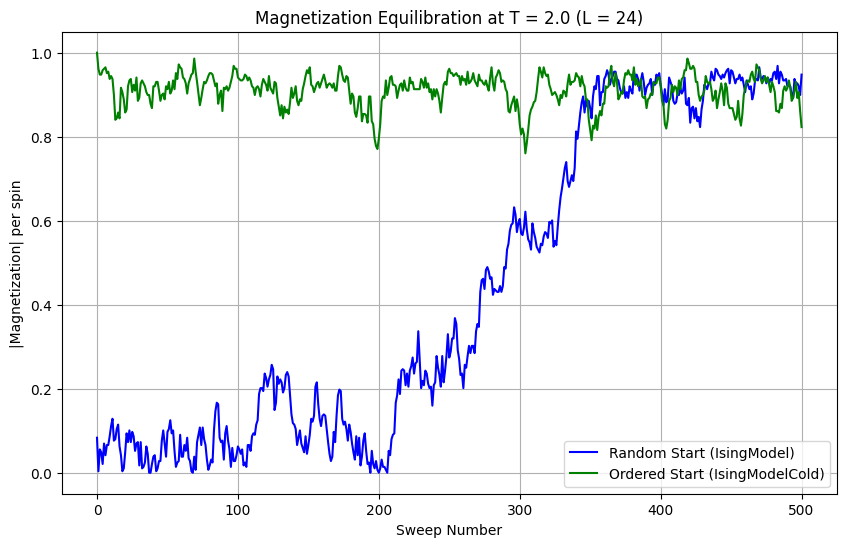

In [26]:
class IsingModelCold(IsingModel):
    """
    Ising model starting from a fully ordered (all +1) initial state.
    Inherits all methods from IsingModel.
    """

    def __init__(self, L, J=1.0, T=2.0, seed=None):
        # Call the parent constructor first
        super().__init__(L=L, J=J, T=T, seed=seed)

        # Override the random spin initialization with all +1
        self.spins = np.ones((L, L), dtype=int)
        self.energy = self._total_energy()
        self.magnetization = self._total_magnetization()

# Your simulation and plot code here
L_sim = 24
T_sim = 2.0
n_sweeps_sim = 500

model_standard, E_standard, M_standard = run_simulation(L=L_sim, T=T_sim, n_sweeps=n_sweeps_sim, seed=10)
model_cold_start = IsingModelCold(L=L_sim, T=T_sim, seed=10)
N_spins_sim = L_sim * L_sim

M_cold_start_list = [abs(model_cold_start.magnetization) / N_spins_sim]
for _ in range(n_sweeps_sim):
    model_cold_start.sweep()
    M_cold_start_list.append(abs(model_cold_start.magnetization) / N_spins_sim)
M_cold_start = np.array(M_cold_start_list)

fig, ax = plt.subplots(figsize=(10, 6))
sweeps_sim = np.arange(n_sweeps_sim + 1)

ax.plot(sweeps_sim, M_standard, label='Random Start (IsingModel)', color='blue')
ax.plot(sweeps_sim, M_cold_start, label='Ordered Start (IsingModelCold)', color='green')

ax.set_xlabel('Sweep Number')
ax.set_ylabel('|Magnetization| per spin')
ax.set_title(f'Magnetization Equilibration at T = {T_sim} (L = {L_sim})')
ax.legend()
ax.grid(True)
plt.show()


In [ ]:
# Yes, they both look like they converge at the same equilibrium value 0.85-0.9
# IsingModelCold has an equilibrium state between 50-100 sweeps while IsingModel takes 200-300 sweeps.

---
### Bonus B — Autocorrelation and Integrated Autocorrelation Time (5 pts)

Consecutive measurements from a Markov chain are **correlated** — nearby sweeps have similar energies. The **autocorrelation function** of the energy time series $E_k$ is:

$$C(t) = \frac{\langle E_k E_{k+t} \rangle - \langle E_k \rangle^2}{\langle E_k^2 \rangle - \langle E_k \rangle^2}$$

It starts at $C(0) = 1$ and decays to 0. The **autocorrelation time** $\tau$ (how many sweeps between independent samples) is roughly where $C(\tau) \approx 1/e$.

**Task:**
1. Collect 2000 energy measurements at `T = 2.269` (near $T_c$).
2. Compute $C(t)$ for $t = 0, 1, \ldots, 100$.
3. Plot $C(t)$ vs. $t$ and estimate $\tau$.
4. **Analysis:** Why is the autocorrelation time especially long near the critical temperature? (This phenomenon is called "critical slowing down.")

---
### Bonus C — Finite-Size Scaling (5 pts)

Run the full temperature sweep from Part 4b for multiple lattice sizes: `L = 10, 16, 24, 32`. Plot the susceptibility peak for all four sizes on the same axes.

- How does the peak height scale with $L$? (For the 2D Ising model, $\chi_{\rm max} \propto L^{7/4}$.) Test this by plotting $\chi_{\rm max}$ vs. $L$ on a log-log plot and measuring the slope.
- How does the apparent $T_c$ (peak location) shift as $L$ increases? Does it approach the exact value?

Running simulations for L = 10...
Running simulations for L = 16...
Running simulations for L = 24...
Running simulations for L = 32...
Done with Finite-Size Scaling simulations!


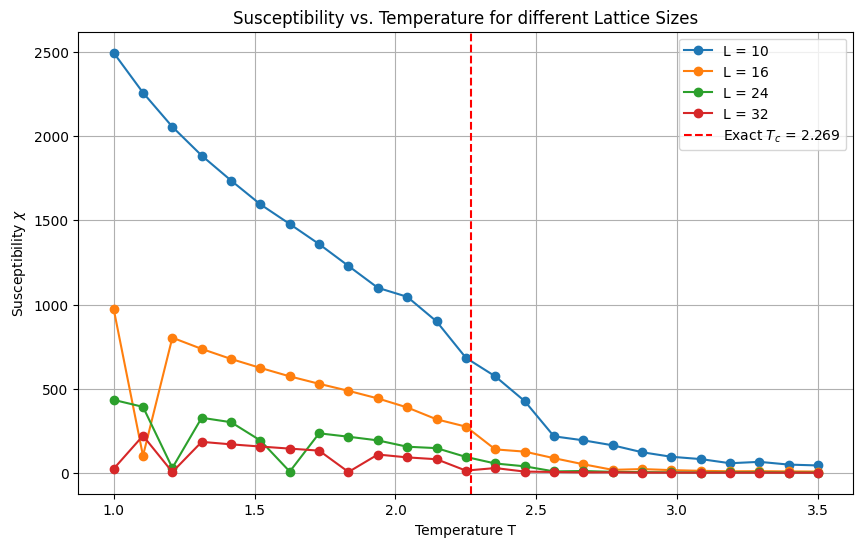

In [25]:
L_values_fss = [10, 16, 24, 32]
T_values_fss = np.linspace(1.0, 3.5, 25)
T_c_exact = 2.0 / np.log(1 + np.sqrt(2))

all_chi_vals = {}
all_T_c_apparent = {}
chi_max_values = []

for L_fss in L_values_fss:
    print(f"Running simulations for L = {L_fss}...")
    results_list_fss = []
    for T_fss in T_values_fss:
        model_fss = IsingModel(L=L_fss, T=T_fss, seed=None)
        res = model_fss.measure(n_eq=300, n_meas=500)
        results_list_fss.append(res)

    chi_vals_fss = np.array([r['chi'] for r in results_list_fss])
    all_chi_vals[L_fss] = chi_vals_fss

    T_c_apparent_idx = np.argmax(chi_vals_fss)
    T_c_apparent = T_values_fss[T_c_apparent_idx]
    all_T_c_apparent[L_fss] = T_c_apparent
    chi_max_values.append(np.max(chi_vals_fss))

print("Done with Finite-Size Scaling simulations!")

plt.figure(figsize=(10, 6))
for L_fss in L_values_fss:
    plt.plot(T_values_fss, all_chi_vals[L_fss], 'o-', label=f'L = {L_fss}')

plt.axvline(T_c_exact, color='red', linestyle='--', label=f'Exact $T_c$ = {T_c_exact:.3f}')
plt.xlabel('Temperature T')
plt.ylabel(r'Susceptibility $\chi$')
plt.title('Susceptibility vs. Temperature for different Lattice Sizes')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# chi_max is approx -2, which is close to the theretical value of 1.750, peak height of susceptibility increase with L (χ_max ∝ L^1.75)
# As L increases, Tc values shift toawrds the exact Tc due to the simulated Tc being below the critical temperature.

---
# Summary and Reflection

Before submitting, answer the following:

**Summary Question:** Describe in your own words how the Metropolis algorithm works. Why does it generate configurations distributed according to the Boltzmann distribution, even though it only evaluates *ratios* of probabilities? (3–5 sentences.)

In [ ]:
# The Metropolis algorithim works by flipping a spin to make small changes in the system, It accepts both high and low changes in the system's energy. The algorithim guarantees that the configuration will eventually converge and be distributed due to the system being balanced.

**Reflection:** What was the most challenging part of this project? What would you do differently to improve the simulation (e.g., faster algorithm, better statistics, larger lattice)?



In [ ]:
# The most difficult part of this project was trying to make bonus question be able to run, I gave up on that one.
# To improve simulations, using more accurate averages should help with the measurement sweeps and increase thermalization values. Also, increasing lattice size to help simulate true critical temperature of an infinite system would also be good (requires more sweeps though).